In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

In [2]:
data = pd.read_excel("prediction_data.xlsx", sheet_name= "vw_ChurnData")

In [3]:
data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,11098-MAD,Female,30,Yes,Madhya Pradesh,0,31,Deal 1,Yes,No,...,Bank Withdrawal,951,66834,0,0,63172,731512,Stayed,Others,Others
1,11114-PUN,Male,51,No,Punjab,5,9,Deal 5,Yes,No,...,Bank Withdrawal,4915,16905,0,10,12237,30142,Churned,Competitor,Competitor had better devices
2,11167-WES,Female,43,Yes,West Bengal,3,28,Deal 1,Yes,Yes,...,Bank Withdrawal,11605,82975,4257,110,187298,1023791,Stayed,Others,Others
3,11179-MAH,Male,35,No,Maharashtra,10,12,NaN,Yes,No,...,Credit Card,844,59693,0,0,21939,618869,Stayed,Others,Others
4,11180-TAM,Male,75,Yes,Tamil Nadu,12,27,Deal 2,Yes,No,...,Credit Card,726,408435,0,140,33208,455643,Stayed,Others,Others


In [4]:
original_data = data.copy()

In [5]:
## DROP delel colonne che non verranno utilizzate nel modello predittivo
data.drop(columns=['Customer_ID','Churn_Category','Churn_Reason'], inplace=True)

In [6]:
# Convertiamo le variabili categoriche (testuali) in valori numerici,
# un passaggio necessario per molti algoritmi di machine learning.
# Prima, definisce una lista di colonne (columns_to_encode) che contengono dati categorici.
# Poi, itera su ciascuna di queste colonne, creando per ognuna un oggetto LabelEncoder.
# Trasforma una categoria in un numero intero arbitrario.
# Questo encoder assegna un numero intero unico a ciascun valore categorico presente nella colonna
# (ad esempio, 'Yes' potrebbe diventare 1 e 'No' potrebbe diventare 0),
# e poi sostituisce i valori originali nella colonna del DataFrame con questi numeri.
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]

# Encode categorical variables except the target variable
label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# Lo facciamo manualmente perchè ci interessa che 1 sia churned e 0
data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})


In [7]:
data.head()

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
0,0,30,1,11,0,31,0,1,0,1,...,2,0,0,951,66834,0,0,63172,731512,0
1,1,51,0,15,5,9,4,1,0,1,...,0,1,0,4915,16905,0,10,12237,30142,1
2,0,43,1,21,3,28,0,1,1,1,...,2,1,0,11605,82975,4257,110,187298,1023791,0
3,1,35,0,12,10,12,5,1,0,1,...,2,1,1,844,59693,0,0,21939,618869,0
4,1,75,1,17,12,27,1,1,0,1,...,2,1,1,726,408435,0,140,33208,455643,0


In [8]:
# separazione dei dati in feature e target per poi fare il train test split
X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

# split train test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Training del modello Random Forest
# inizializziamo il modello
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Addestriamo il modello
# se facessi il tarin con x_train  e x_test starei compiendo un errore
# che prende il nome di data leakage
# dà metriche artificialmente buone che non rispecchiano le performance reali.
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
y_pred = rf_model.predict(x_test)

Confusion Matrix:
[[759  88]
 [129 226]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       847
           1       0.72      0.64      0.68       355

    accuracy                           0.82      1202
   macro avg       0.79      0.77      0.78      1202
weighted avg       0.81      0.82      0.82      1202



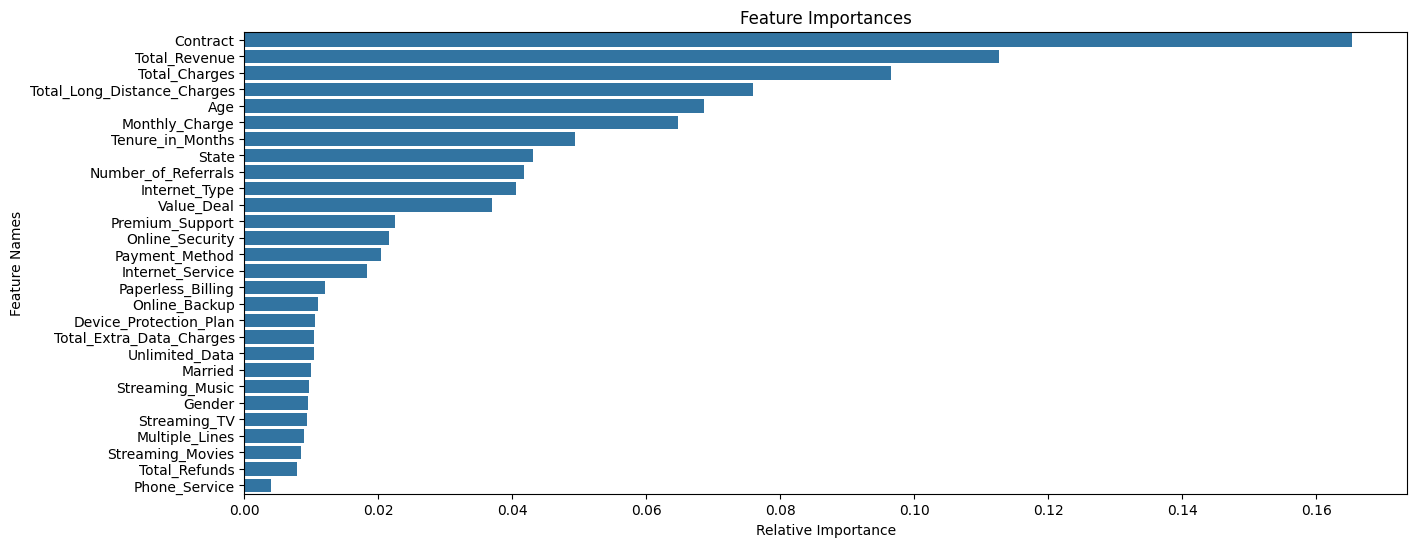

In [11]:
# valutazione del modello
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))# matrice di confusione
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Selezioniamo le feature più importanti che incisono sullo status churn
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plottiamo le features
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()


In [12]:
"""
True Negative (TN) = 759 — clienti rimasti e il modello ha correttamente predetto che restano
False Positive (FP) = 88 — clienti rimasti ma il modello ha predetto che avrebbero churned (falso allarme)
False Negative (FN) = 129 — clienti churned ma il modello ha predetto che sarebbero rimasti (il caso più pericoloso)
True Positive (TP) = 226 — clienti churned e il modello ha correttamente predetto il churn
"""


'\nTrue Negative (TN) = 759 — clienti rimasti e il modello ha correttamente predetto che restano\nFalse Positive (FP) = 88 — clienti rimasti ma il modello ha predetto che avrebbero churned (falso allarme)\nFalse Negative (FN) = 129 — clienti churned ma il modello ha predetto che sarebbero rimasti (il caso più pericoloso)\nTrue Positive (TP) = 226 — clienti churned e il modello ha correttamente predetto il churn\n'

Il principio che c'è sotto

È il concetto di dati etichettati vs non etichettati:

Stayed/Churned  →  hanno una label  →  usati per ADDESTRARE

Joined          →  non hanno label  →  usati per PREDIRE

Questo schema si chiama apprendimento supervisionato: il modello impara da chi ha già una risposta, e poi la applica a chi non ce l'ha ancora.

In [13]:
data2 = pd.read_excel("prediction_data.xlsx", sheet_name= "vw_JoinedData")

In [14]:
# copia del dataframe originale prima dell'encoding
original_data2 = data2.copy()

# teniamo da parte i customer id
customer_ids = data2['Customer_ID']

# Drop colonne  inutili
data2.drop(columns=['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], inplace= True)

# Encoding delle variabili categoriche
for column in data2.select_dtypes(include=['object']).columns:
    data2[column] = label_encoders[column].transform(data2[column])

# predictions
new_predictions = rf_model.predict(data2)


In [16]:
original_data2['Customer_Status_Predicted'] = new_predictions

# Filtriamo solo i clienti "Churned" predetti come 1 (ovvero quelli joined ma potenzialmente a rischio)
original_data2 = original_data2[original_data2['Customer_Status_Predicted'] == 1]

In [18]:
original_data2.to_csv(r"Predictions.csv", index=False)